# Neural tissue segmentation with simulated training data

## 1. Preparing the data to segment

Start by downloading the data

In [1]:
import os
import deeptrack as dt

if not os.path.exists("tissue_images_dataset"):
    os.system("git clone https://github.com/DeepTrackAI/tissue_images_dataset")

raw_path = os.path.join("tissue_images_dataset", "stack1", "raw")
seg_path = os.path.join("tissue_images_dataset", "stack1", "labels")

raw_paths = dt.sources.ImageFolder(root=raw_path)
seg_paths = dt.sources.ImageFolder(root=seg_path)
path = dt.sources.Source(raw=raw_paths, label=seg_paths)
srcs = path.product(flip_ud=[True, False], flip_lr=[True, False])

sources = dt.sources.Join(srcs)

print(f"Raw images: {len(raw_paths)}")
print(f"Segmentation labels: {len(seg_paths)}")

C:\Users\xgrmir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\deeptrack\__init__.py:14: UserWarning: TensorFlow is detected in your environment. DeepTrack2 version 2.0++ no longer supports TensorFlow. If you need TensorFlow support, please install the legacy version 1.7 of DeepTrack2:

    pip install deeptrack==1.7

For more details, refer to the DeepTrack documentation.
  warnings.warn(
C:\Users\xgrmir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Raw images: 20
Segmentation labels: 20


### 1.1 Create data pipeline
To get images and segmentation masks

In [2]:
import numpy as np

def select_labels(class_labels):
    """Create a function to filter and remap labels in a segmentation map."""
    def inner(segmentation):
        seg = segmentation.copy()
        mask = seg * np.isin(seg, class_labels).astype(np.uint8)
        new_seg = (np.select([mask == c for c in class_labels],
                             np.arange(len(class_labels)) + 1)
                   .astype(np.uint8).squeeze())
        one_hot_encoded_seg = np.eye(len(class_labels) + 1)[new_seg]
        return one_hot_encoded_seg        
    return inner

In [3]:
import torch

im_pip_exp = dt.LoadImage(sources.raw.path) >> dt.NormalizeMinMax()
seg_pip_exp = (dt.LoadImage(sources.label.path)
           >> dt.Lambda(select_labels, class_labels=[255, 191]))
pip_exp = ((im_pip_exp & seg_pip_exp) >> dt.FlipLR(sources.flip_lr)
       >> dt.FlipUD(sources.flip_ud) >> dt.MoveAxis(2, 0)
       >> dt.pytorch.ToTensor(dtype=torch.float))

In [4]:
exp_dataset = dt.pytorch.Dataset(pip_exp, srcs)

### 1.2 Visualize an experimental sample

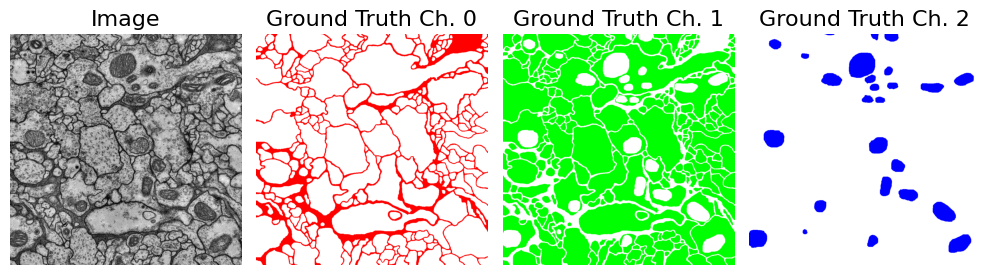

In [5]:
import matplotlib.pyplot as plt

image, segmentation = exp_dataset[0]

fig, axs = plt.subplots(1, 4, figsize=(10, 5))

axs[0].imshow(image.permute(1, 2, 0), cmap="gray")
axs[0].set_title("Image", fontsize=16)
axs[0].set_axis_off()

for i in range(segmentation.shape[0]):
    segmentation_color = torch.ones_like(segmentation)
    for j in range(segmentation.shape[0]):
        if j != i: segmentation_color[j, ...] = 1 - segmentation[i, ...]
    axs[i + 1].imshow(segmentation_color.permute(1, 2, 0))
    axs[i + 1].set_title(f"Ground Truth Ch. {i}", fontsize=16)
    axs[i + 1].set_axis_off()

plt.tight_layout()
plt.show()

To decrease the training speed: simulate images 1/4 of the size of the experimental images

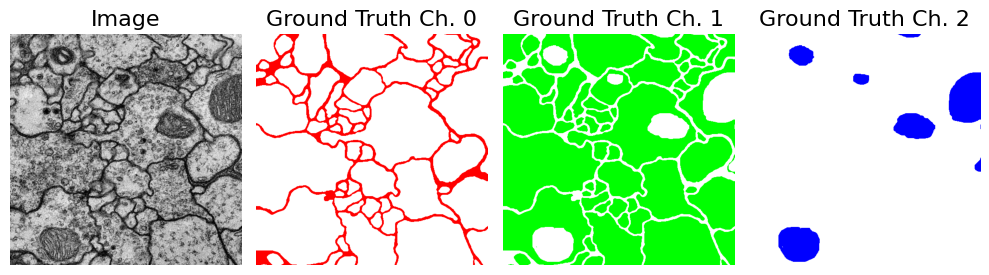

In [6]:
image, segmentation = exp_dataset[0]

size = image.shape[1]//2

image = image[:, :size, :size]
segmentation = segmentation[:, :size, :size]

fig, axs = plt.subplots(1, 4, figsize=(10, 5))

axs[0].imshow(image.permute(1, 2, 0), cmap="gray")
axs[0].set_title("Image", fontsize=16)
axs[0].set_axis_off()

for i in range(segmentation.shape[0]):
    segmentation_color = torch.ones_like(segmentation)
    for j in range(segmentation.shape[0]):
        if j != i: segmentation_color[j, ...] = 1 - segmentation[i, ...]
    axs[i + 1].imshow(segmentation_color.permute(1, 2, 0))
    axs[i + 1].set_title(f"Ground Truth Ch. {i}", fontsize=16)
    axs[i + 1].set_axis_off()

plt.tight_layout()
plt.show()

## 2. Simulate the data

### 2.1 Membrane

In [7]:
import cv2
from scipy.spatial import Voronoi


class Membrane(dt.Feature):
    def __init__(
        self,
        image_size,
        num_points=40,
        num_clusters=4,
        num_random_points=15,
        thickness=4,
        fill_probability=0.2,
        mitochondria_sites=None,
        mitochondria_size=None,
        **kwargs
    ):
        super().__init__(  # all the variables for the "get" seem to have to be here. Otherwise, they don't work with lambda functions
            image_size=image_size,
            num_points=num_points,
            num_clusters=num_clusters,
            num_random_points=num_random_points,
            thickness=thickness,
            mitochondria_sites=mitochondria_sites,
            mitochondria_size=mitochondria_size,
            **kwargs,
        )

        self.fill_probability = fill_probability

    # def _process_properties(self, properties):
        
    #     # Rescales the position property.
    #     properties = super()._process_properties(properties)
    #     self._processed_properties = True
    #     return properties

    def generate_clustered_points(
        self, image_size, num_clusters, num_points, num_random_points
    ):

        # create cluster locations and standard deviations
        cluster_centers = np.random.uniform(
            -0.075 * image_size, 1.075 * image_size, size=(num_clusters, 2)
        )
        cluster_stds = np.random.uniform(
            0.05 * image_size, 0.1 * image_size, size=(num_clusters, 2)
        )

        # randomly put points into clusters
        cluster_ids = np.random.choice(num_clusters, size=num_points)

        # these points get positions from the distribution they belong to
        clustered_points = np.random.normal(
            loc=cluster_centers[cluster_ids], scale=cluster_stds[cluster_ids]
        )

        # add random points
        if num_random_points > 0:
            random_points = np.random.uniform(
                -0.3 * image_size,
                1.3 * image_size,
                size=(num_random_points, 2),
            )
            points = np.vstack([clustered_points, random_points])

        else:
            points = clustered_points

        return points

    def draw_line(self, start, end, mask, thickness):
        cv2.polylines(
            mask,
            [np.array([start, end], dtype=np.int32)],
            isClosed=False,
            color=1,
            thickness=thickness,
        )

    def get(
        self,
        image,
        image_size,
        num_clusters,
        num_points,
        num_random_points,
        thickness,
        **kwargs
    ):
        points = self.generate_clustered_points(
            image_size=image_size,
            num_clusters=num_clusters,
            num_points=num_points,
            num_random_points=num_random_points,
        )

        vor = Voronoi(points)

        mask = np.zeros((image_size, image_size, 1), dtype=float)

        for ridge in vor.ridge_vertices:
            if -1 not in ridge:
                start = vor.vertices[ridge[0]]
                end = vor.vertices[ridge[1]]
                self.draw_line(start, end, mask, thickness)

        areas = []
        centroids = []

        # Fill some small areas & find big areas for placing mitochondria
        for region_idx in vor.point_region:
            region = vor.regions[region_idx]
            if not -1 in region and len(region) > 0:
                polygon = np.array(
                    [vor.vertices[i] for i in region], dtype=np.int32
                )

                # Compute polygon area
                area = cv2.contourArea(polygon)
                relative_area = area / (image_size * image_size)

                # Map area to a probability: small → larger fill probability,
                # large → small fill probability
                size_factor = np.exp(-relative_area * 40)

                # Final probability
                p = self.fill_probability * size_factor

                # Fill
                if np.random.rand() < p:
                    cv2.fillPoly(mask, [polygon], 1)

                # Find centroid of the polygon
                M = cv2.moments(polygon)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    centroid = (cy, cx)

                    # only store the position if the centroid is inside the
                    # image boundaries
                    if (
                        (cx > 0)
                        & (cx < image_size)
                        & (cy > 0)
                        & (cy < image_size)
                    ):

                        # only store if the centroid is not in a filled area
                        if mask[cy, cx] == 0:

                            # store centroid and area
                            areas.append(area)
                            centroids.append(centroid)

        # Keep top 10 largest
        top_idx = np.argsort(areas)[-10:]
        self.mitochondria_sites = np.array([centroids[i] for i in top_idx])
        self.mitochondria_size = np.array([areas[i] for i in top_idx])

        return mask + image

In [8]:
import scipy.ndimage as ndi

class Erode(dt.Feature):

    def __init__(self, iterations=1, **kwargs):
        super().__init__(iterations=iterations, **kwargs)

    def get(self, image, iterations, **kwargs):

        image = np.asarray(image[:, :, 0], dtype=int)

        eroded = ndi.binary_erosion(image, iterations=iterations)

        return np.expand_dims(eroded, axis=2)

In [9]:
image_size = 512

# pad image to reduce edge effects of the membrane simulation
pad = 10
image_size_padded = image_size + 2 * pad

membrane = Membrane(
    image_size=image_size_padded,
    num_points=lambda: np.random.randint(35, 45),
    num_clusters=lambda: np.random.randint(4, 6),
    num_random_points=15,
    thickness=4,
)

In [10]:
mem_pip = (
    dt.Value(np.zeros((image_size_padded, image_size_padded, 1), dtype=float))
    >> membrane
    >> dt.ElasticTransformation(alpha=1000, sigma=14)
    >> dt.ElasticTransformation(alpha=10, sigma=5)
    >> dt.AverageBlur(ksize=7)
    >> dt.ElasticTransformation(alpha=10, sigma=2.8)

    # Threshold at 0.25...
    # >> dt.GreaterThan(0.25)

    # .. or at a lower value + use erosion?
    >> dt.GreaterThan(0.09) # 0.02
    >> Erode(iterations=2)  # 3
)

#### Plotting

In [11]:
# mem_pip.update()
# im = mem_pip.resolve()

# fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# ax[0].imshow(im, cmap='gray_r')
# ax[0].set_xlim(pad, image_size_padded-pad)
# ax[0].set_ylim(pad, image_size_padded-pad)
# ax[0].set_title('Simulated')
# ax[1].imshow(1 - segmentation[0, ...], cmap='gray')
# ax[1].set_title('From exp dataset');

In [12]:
# mem_pip.update()
# im = mem_pip.resolve()

# fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# ax[0].imshow(im, cmap='gray_r')
# ax[0].set_xlim(pad, image_size_padded-pad)
# ax[0].set_ylim(pad, image_size_padded-pad)
# ax[0].set_title('Simulated')
# ax[1].imshow(im, cmap='gray_r')
# ax[1].set_xlim(pad, image_size_padded-pad)
# ax[1].set_ylim(pad, image_size_padded-pad)
# ax[1].set_title('Simulated with possible mitochondria placements')

# s = membrane.mitochondria_sites
# r = membrane.mitochondria_size
# ax[1].scatter(s[:, 1], s[:, 0], c='b', s=5e-5*r**1.8);

### 2.2 Mitochondria

In [13]:
def random_ellipse_axes(ellipse_area):
    """Return the three axes of an ellipse."""
    radius_ratio = np.random.beta(1, 3.5) + 1
    major_axis = np.sqrt(ellipse_area) * radius_ratio
    minor_axis = np.sqrt(ellipse_area) / radius_ratio
    z_axis = 0.25
    return (major_axis, minor_axis, z_axis) * dt.units.um

In [14]:
def sample_mito(membrane):
    """Pick a mitochondrion. Return its position and size."""

    idx = np.random.randint(0, len(membrane.mitochondria_sites))
    pos = membrane.mitochondria_sites[idx]
    size = membrane.mitochondria_size[idx]

    return pos, size

In [15]:
indices = []
i = -1
_current_mito = None

def next_mito():
    global indices, i, _current_mito

    # Refill + shuffle if empty
    if len(indices) == 0:
        indices = list(range(len(membrane.mitochondria_sites)))
        np.random.shuffle(indices)
        i = -1

    # Take the next index
    i = indices.pop()

    position = membrane.mitochondria_sites[i]
    size = membrane.mitochondria_size[i]
    axes = random_ellipse_axes(size**1.75 * 1.6e-7)

    _current_mito = (position, axes)
    return _current_mito


def mito_position():
    next_mito()
    return _current_mito[0]


def mito_axes():
    return _current_mito[1]


ellipse = dt.Ellipsoid(
    radius=mito_axes,
    intentensity=1.5,
    position=mito_position,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

clean_mitochondria = (
    ellipse ^ (lambda: int(np.random.beta(10, 5) * 5))
) >> dt.ElasticTransformation(alpha=70, sigma=8, order=1, ignore_last_dim=True)

mitochondria = (
    clean_mitochondria
    >> dt.Pad(px=(10, 10, 10, 10))
    >> dt.ElasticTransformation(
        alpha=100,
        sigma=lambda: np.random.uniform(3, 5),
        order=1,
        ignore_last_dim=False,
    )
    >> dt.ElasticTransformation(
        alpha=70, sigma=8, order=1, ignore_last_dim=True
    )
    >> dt.CropTight()
)

noise_mitochondria = mitochondria >> dt.Poisson(
    snr=lambda: np.random.uniform(4.5, 6)
)
noisy_mitochondria = mitochondria * noise_mitochondria

### 2.3 Noise

Noisy background areas

In [16]:
noisy_areas = dt.Ellipse(
    radius=lambda: np.random.uniform(0.5, 5, 2)*1e-6,
    intensity=lambda: np.random.uniform(-0.1, 0.3),
    position=lambda: np.random.uniform(0, image_size_padded, size=2),
    z=0, 
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

noisy_areas = ((noisy_areas) ^ 200) >> dt.ElasticTransformation(alpha=100, sigma=1, order=1)
noise_gaussian = (noisy_areas >> dt.Gaussian(sigma=0.5))
noisy_areas = noisy_areas  * noise_gaussian

Speckle noise

In [17]:
speckle_ellipse = dt.Ellipse(
    radius=lambda: np.random.uniform(0.5, 1, 2)*1e-6,
    intensity=lambda: np.random.uniform(-0.8, 1),
    position=lambda: np.random.uniform(0, image_size_padded, size=2),
    z=0, 
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

speckle_noise = ((speckle_ellipse) ^ 500) >> dt.ElasticTransformation(alpha=50, sigma=7, order=1)
speckle_gaussian1 = (speckle_noise >> dt.Gaussian(sigma=0.7))
speckle_poisson1 = (speckle_noise >>  dt.Poisson(snr=0.3, background=1e-4))
speckle_noise = speckle_noise  * speckle_gaussian1 * speckle_poisson1

Dark spots

In [18]:
dark_spot = dt.Ellipsoid(
    radius=lambda: (
        np.random.uniform(0.35, 0.75),
        np.random.uniform(0.35, 0.75),
        np.random.uniform(0.45, 0.75),
    )
    * dt.units.um,
    intensity=lambda: np.random.uniform(1, 5),
    position=lambda: np.random.uniform(0, image_size_padded, size=2),
    z=0,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

dark_spots = (
    (dark_spot) ^ (lambda: np.random.randint(10, 20))
) >> dt.ElasticTransformation(alpha=50, sigma=7, order=1)

Noisy ellipses

In [19]:
noise_ellipse = dt.Ellipse(
    radius=lambda: np.random.uniform(0.5, 3, 2) * 1e-6,
    intensity=lambda: np.random.uniform(-1, 1.5),
    position=lambda: np.random.uniform(0, image_size_padded, size=2),
    z=0,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

noisy_ellipses = ((noise_ellipse) ^ 100) >> dt.ElasticTransformation(
    alpha=50, sigma=7, order=1
)
ellipse_gaussian = noisy_ellipses >> dt.Gaussian(sigma=5)
ellipse_poisson = noisy_ellipses >> dt.Poisson(snr=0.5, background=1e-4)
noisy_ellipses = noisy_ellipses * ellipse_gaussian * ellipse_poisson

Noisy stripes

In [20]:
stripe = dt.Ellipse(
    radius=lambda:(
       np.random.uniform(2, 10),   # major axis
       np.random.uniform(0.2, 0.6),   # minor axis
    ) * dt.units.um,
    intensity=lambda: np.random.uniform(-1, 1),
    position=lambda: np.random.uniform(0, image_size_padded, size=2),
    z=0,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

noisy_stripes = ((stripe) ^ 8) >> dt.ElasticTransformation(alpha=50, sigma=7, order=1)
noise_gaussian_s = (noisy_stripes >> dt.Gaussian(sigma=0.3))
noisy_stripes = noisy_stripes  * noise_gaussian_s

### 2.4 Optics

In [21]:
optics = dt.Brightfield(
    wavelength=400e-9,
    NA=lambda: np.random.uniform(0.9, 1.1),
    output_region=(0, 0, image_size_padded, image_size_padded),
)

optics_f = dt.Fluorescence(
    output_region=(0, 0, image_size_padded, image_size_padded),
)

In [22]:
from scipy.ndimage import zoom

base_size = 16
zoom_factor = image_size_padded / base_size

gray_mask_fn = lambda: zoom(
    np.clip(np.random.normal(loc=0.7, scale=0.2, size=(base_size, base_size)), 0.5, 1.0),
    zoom=zoom_factor, 
    order=4  # cubic interpolation for smoothing
)[..., None]

### 2.5 Masks and pipelines

In [37]:
from skimage import morphology as skmorph


def get_mask(radius):
    def inner(mask):
        mask = np.sum(mask, -1, keepdims=True) > 0
        mask = np.pad(mask, [(1, 1), (1, 1), (0, 0)], mode="constant")
        mask = skmorph.isotropic_erosion(mask, radius)
        return mask[1:-1, 1:-1]

    return inner


mito_pip = optics(noisy_mitochondria) - 0.7 * (
    noisy_mitochondria
    >> dt.SampleToMasks(
        get_mask,
        radius=0,
        output_region=optics.output_region,
        merge_method="or",
    )
)

mito_mask_pip = (
    clean_mitochondria
    >> dt.SampleToMasks(
        get_mask,
        radius=0,
        output_region=optics.output_region,
        merge_method="or",
    )
    >> dt.AsType("float")
)

base_pip = (
    gray_mask_fn * mem_pip * (-1) + 0.7 * mito_pip - 30 * optics_f(noisy_areas)
    >> dt.GaussianBlur(sigma=0.9)
    >> dt.Gaussian(sigma=lambda: np.random.uniform(0.06, 0.09), order=0)
)

im_pip = (
    base_pip
    + 0.7 * optics(speckle_noise >> dark_spots >> noisy_stripes)
    + 0.4 * optics(noisy_ellipses)
    >> dt.Clip(0.7, 1.9)
    >> dt.AverageBlur(ksize=lambda: 2 * int(np.random.randint(0, 2) + 1))
    >> dt.Poisson(snr=lambda: np.random.uniform(50, 100))
    >> dt.Gaussian(sigma=lambda: np.random.uniform(0.06, 0.09), order=0)
    >> dt.Clip(0.6, 3)
    >> dt.NormalizeMinMax()
)

pip = (
    (im_pip & mem_pip & mito_mask_pip)
    >> dt.Crop(crop=(image_size, image_size, 1), corner=(pad, pad))
    >> dt.MoveAxis(2, 0)
    >> dt.pytorch.ToTensor(dtype=torch.float)
)

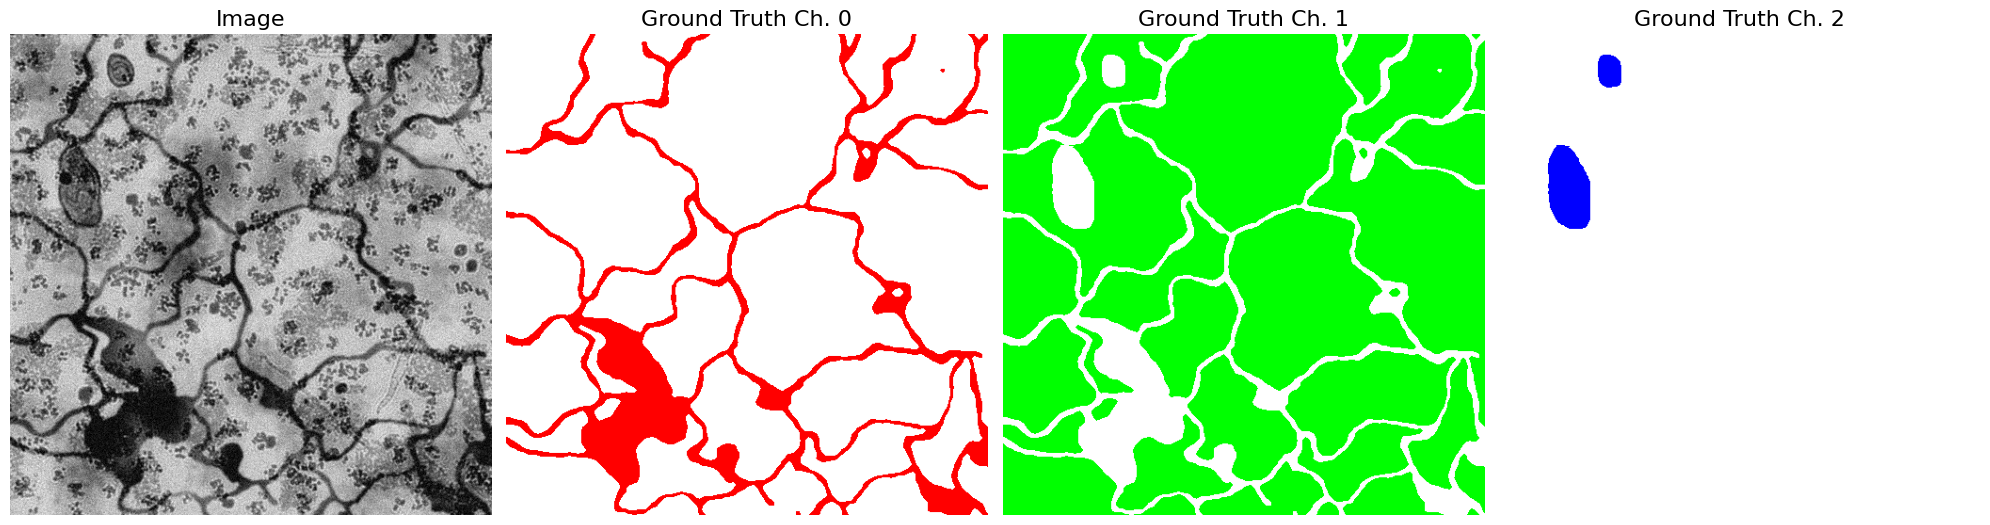

In [50]:
pip.store_properties()
pip.update()

im, mem_mask, mito_mask = pip.resolve()
im = torch.as_tensor(im)
mem_mask = torch.as_tensor(mem_mask)
mito_mask = torch.as_tensor(mito_mask)

intra_cellular_mask = torch.ones((image_size, image_size)) - torch.max(mem_mask, mito_mask)
masks = ([mem_mask, intra_cellular_mask, mito_mask])
masks = torch.concat(masks, axis=0)

fig, axs = plt.subplots(1, 4, figsize=(20, 6))

axs[0].imshow(im.permute(1, 2, 0), cmap="gray")
axs[0].set_title("Image", fontsize=16)
axs[0].set_axis_off()

colors = [
    torch.tensor([1.0, 0.0, 0.0]),  # Red
    torch.tensor([0.0, 1.0, 0.0]),  # Green
    torch.tensor([0.0, 0.0, 1.0]),  # Blue
]

for i in range(masks.shape[0]):
    color_mask = torch.ones(3, *masks.shape[1:])  # White background

    for c in range(3):
        color_mask[c][masks[i] > 0.5] = colors[i % len(colors)][c]

    axs[i + 1].imshow(color_mask.permute(1, 2, 0))
    axs[i + 1].set_title(f"Ground Truth Ch. {i}", fontsize=16)
    axs[i + 1].set_axis_off()

plt.tight_layout()
plt.show()

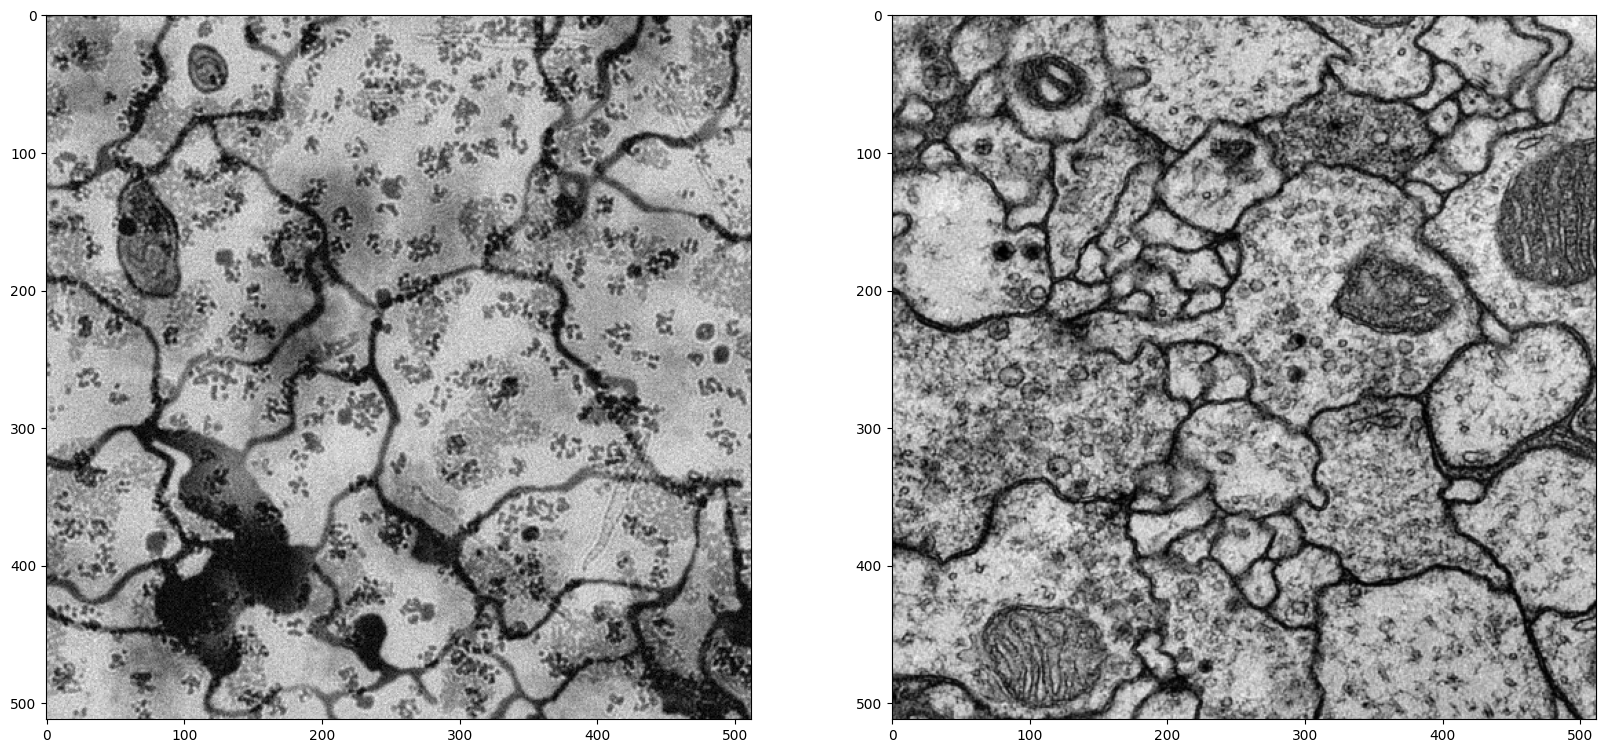

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(im[0], cmap='gray')
ax[1].imshow(image[0], cmap='gray');

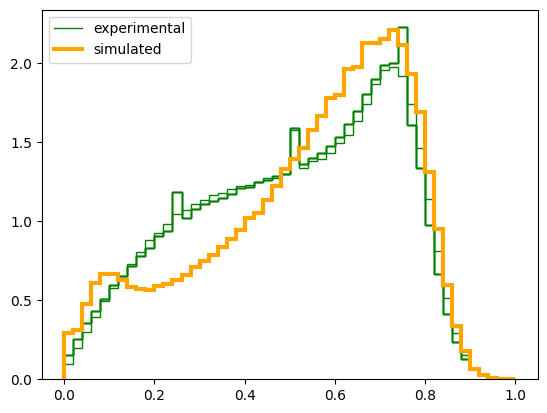

In [52]:
num_bins = 50

for i in range(5):
    image_exp, segmentation = exp_dataset[i]
    hist_exp, bins_exp = np.histogram(image_exp.flatten(), bins=num_bins, density=True)
    if i == 0:
        plt.stairs(hist_exp, bins_exp, label='experimental', color='g')
    else:
        plt.stairs(hist_exp, bins_exp, color='g')


hist, bins = np.histogram(im.flatten(), bins=num_bins, density=True)#, range=[0,1])


# plt.stairs(hist_exp, bins_exp, label='experimental')
plt.stairs(hist, bins, label='simulated', lw=3, color='orange')

plt.legend()

## 3. Create a dataset

In [56]:
num_samples = 1

output = torch.zeros((num_samples, 4, image_size, image_size))

for j in range(num_samples):
    print('sample: ', j)

    pip.update()

    im, mem_mask, mito_mask = pip.resolve()
    im = torch.as_tensor(im)
    mem_mask = torch.as_tensor(mem_mask)
    mito_mask = torch.as_tensor(mito_mask)

    intra_cellular_mask = torch.ones((image_size, image_size)) - torch.max(mem_mask, mito_mask)
    masks = ([mem_mask, intra_cellular_mask, mito_mask])
    masks = torch.concat(masks, axis=0)

    output[j] = torch.concat([im, masks], axis=0)

sample:  0


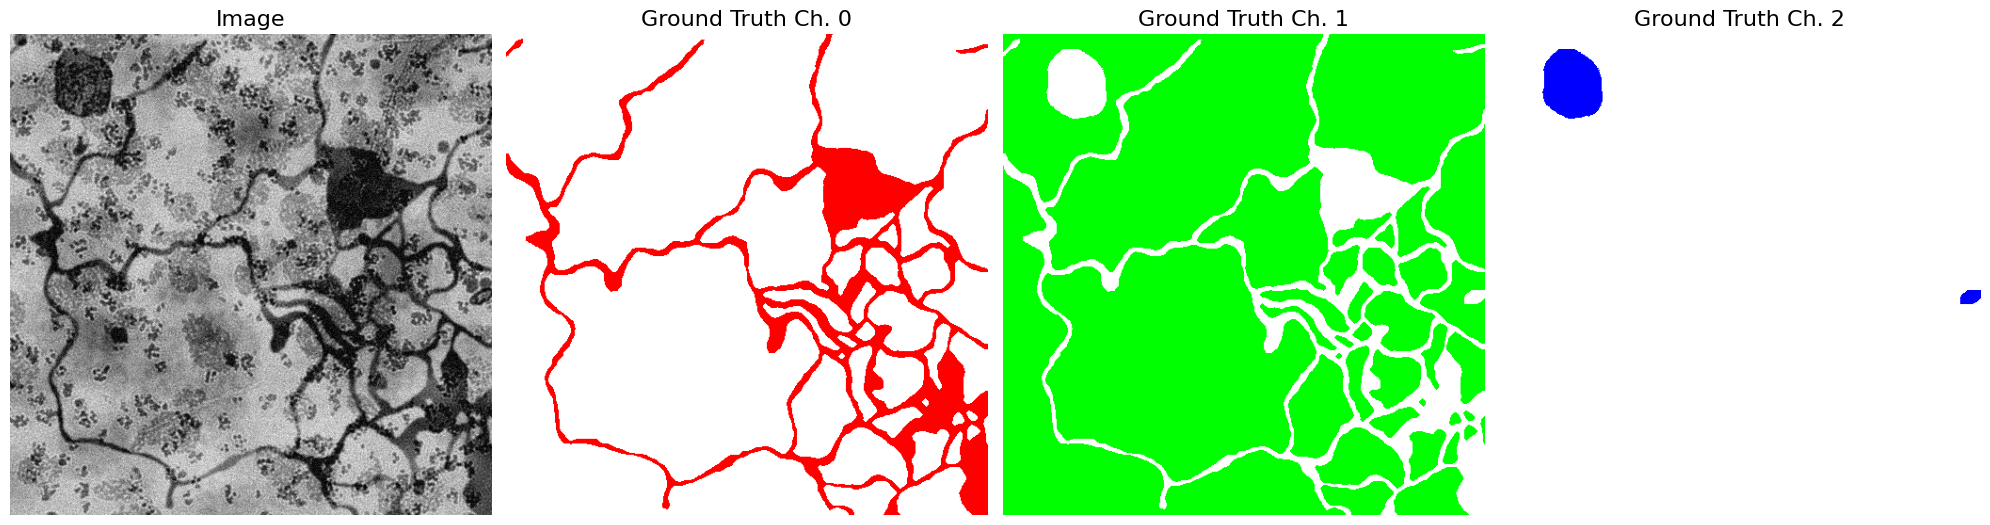

In [57]:
fig, axs = plt.subplots(1, 4, figsize=(20, 6))

axs[0].imshow(im.permute(1, 2, 0), cmap="gray")
axs[0].set_title("Image", fontsize=16)
axs[0].set_axis_off()

colors = [
    torch.tensor([1.0, 0.0, 0.0]),  # Red
    torch.tensor([0.0, 1.0, 0.0]),  # Green
    torch.tensor([0.0, 0.0, 1.0]),  # Blue
]

for i in range(masks.shape[0]):
    color_mask = torch.ones(3, *masks.shape[1:])  # White background

    for c in range(3):
        color_mask[c][masks[i] > 0.5] = colors[i % len(colors)][c]

    axs[i + 1].imshow(color_mask.permute(1, 2, 0))
    axs[i + 1].set_title(f"Ground Truth Ch. {i}", fontsize=16)
    axs[i + 1].set_axis_off()

plt.tight_layout()
plt.show()